STEEPEST DESCENT METHOD WITH EXACT LINE SEARCH
Initial approximation: w0 = [0. 0.]
Converged at iteration 20

QUESTION 8: OPTIMAL SOLUTION AND TOTAL ITERATIONS
Optimal solution: w* = [0.0000000000, 0.9999997491]
Total number of iterations: 21
Final gradient norm: 5.61e-07
Final objective value: -1.0000000000

Analytical solution (for verification): w* = [0.0000000000, 1.0000000000]
Difference from analytical solution: 2.51e-07

QUESTION 7: VERIFICATION OF ORTHOGONALITY CONDITION
Verifying that g_t^T grad(J(w_{t+1})) ≈ 0 at each iteration:
  Iteration 0: g_0^T grad(J(w_1)) = 0.00e+00
  Iteration 1: g_1^T grad(J(w_2)) = 0.00e+00
  Iteration 2: g_2^T grad(J(w_3)) = 0.00e+00
  Iteration 3: g_3^T grad(J(w_4)) = 0.00e+00
  Iteration 4: g_4^T grad(J(w_5)) = 0.00e+00
  ...
  Iteration 15: g_15^T grad(J(w_16)) = 0.00e+00
  Iteration 16: g_16^T grad(J(w_17)) = 0.00e+00
  Iteration 17: g_17^T grad(J(w_18)) = 0.00e+00
  Iteration 18: g_18^T grad(J(w_19)) = 0.00e+00
  Iteration 19: g_19^T grad(J(w_

/var/folders/1y/n1s876vs41n5j660qsm8btcm0000gn/T/ipykernel_51259/1006953135.py:228: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax1.set_ylim(bottom=min(objective_history) * 0.95)
/var/folders/1y/n1s876vs41n5j660qsm8btcm0000gn/T/ipykernel_51259/1006953135.py:228: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=min(objective_history) * 0.95)


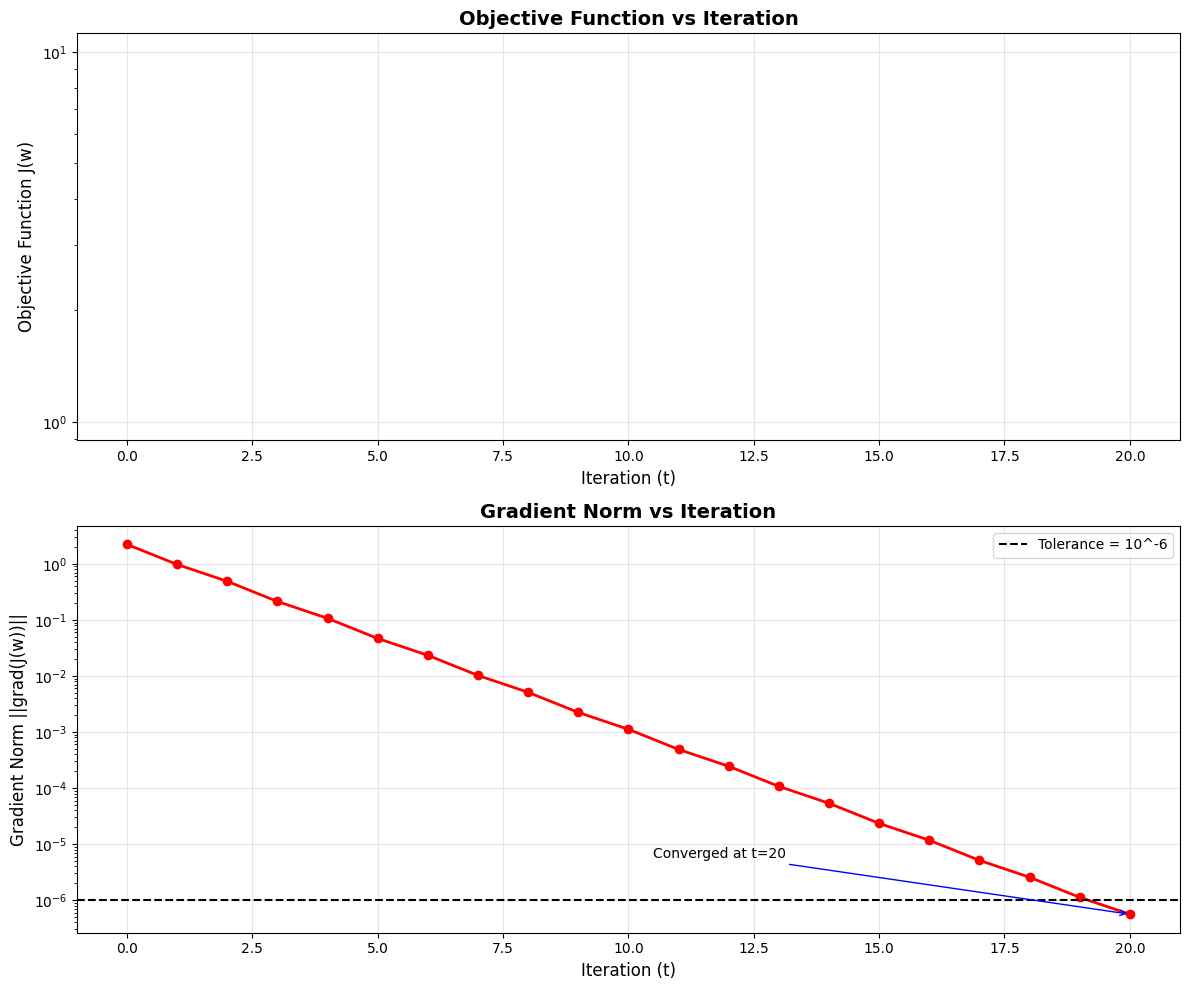

Plots saved as 'steepest_descent_results.png'

CONVERGENCE SUMMARY
Initial objective value:    0.0000000000
Final objective value:      -1.0000000000
Reduction in objective:     1.0000000000
Initial gradient norm:      2.24e+00
Final gradient norm:        5.61e-07
Reduction in gradient norm: 3.99e+06x
Gradient norm decreases monotonically

ITERATION HISTORY
Iteration |    w1        w2     |  ||grad(J)||  |  Objective
------------------------------------------------------------
    0     | 0.000000  0.000000 | 2.24e+00 | 0.000000
    1     | 0.312500  0.625000 | 9.78e-01 | -0.781250
    2     | 0.000000  0.781250 | 4.89e-01 | -0.952148
    3     | 0.068359  0.917969 | 2.14e-01 | -0.989532
    4     | 0.000000  0.952148 | 1.07e-01 | -0.997710
   ...
   18     | 0.000000  0.999999 | 2.56e-06 | -1.000000
   19     | 0.000000  1.000000 | 1.12e-06 | -1.000000
   20     | 0.000000  1.000000 | 5.61e-07 | -1.000000


In [3]:
"""
STEEPEST DESCENT METHOD WITH EXACT LINE SEARCH
For quadratic objective function: J(w) = 1/2 w^T A w - b^T w
where A = [[4, 1], [1, 2]] and b = [1, 2]
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# QUESTION 1: Compute the gradient
# ============================================================================
def gradient(w):
    """
    Compute the gradient of the quadratic objective function
    ∇J(w) = A w - b
    where A = [[4, 1], [1, 2]] and b = [1, 2]
    """
    A = np.array([[4, 1], [1, 2]])
    b = np.array([1, 2])
    return A @ w - b


# ============================================================================
# QUESTION 2: Compute the steepest descent direction
# g_t = -∇J(w_t)
# ============================================================================
def steepest_descent_direction(w):
    """
    Compute the steepest descent direction
    g_t = -∇J(w_t)
    """
    return -gradient(w)


# ============================================================================
# QUESTION 3: Determine the optimal step size
# α_t = arg min J(w_t + α * g_t)
# ============================================================================
def exact_line_search(w, g):
    """
    Find optimal step size α that minimizes J(w + α*g)
    For quadratic function: α = -(g^T ∇J(w)) / (g^T A g)
    
    This is derived by setting d/dα J(w + α*g) = 0
    """
    A = np.array([[4, 1], [1, 2]])
    grad = gradient(w)
    
    # Compute numerator and denominator for optimal α
    numerator = g.T @ grad
    denominator = g.T @ A @ g
    
    # Ensure denominator is positive (A is positive definite)
    if denominator <= 0:
        return 0.0
    
    # Optimal step size for exact line search
    alpha = -numerator / denominator
    return max(0, alpha)  # Ensure non-negative step size


# ============================================================================
# QUESTION 4: Update the parameter vector
# w_{t+1} = w_t + α_t * g_t
# ============================================================================
def update_parameters(w, alpha, g):
    """
    Update the parameter vector using steepest descent step
    w_{t+1} = w_t + α_t * g_t
    """
    return w + alpha * g


# ============================================================================
# QUESTION 5: Continue iterations until ||∇J(w)|| < 10^-6
# ============================================================================
def steepest_descent_exact(w0, tolerance=1e-6, max_iterations=1000):
    """
    Implement Steepest Descent Method with Exact Line Search
    
    Parameters:
    - w0: Initial approximation [0, 0]
    - tolerance: Convergence criterion ||∇J(w)|| < 10^-6
    - max_iterations: Maximum number of iterations allowed
    
    Returns:
    - w_optimal: Final optimal solution
    - w_history: History of all parameter vectors
    - objective_history: History of objective function values
    - gradient_norm_history: History of gradient norms
    - iterations: Total number of iterations performed
    """
    # Initialize with the given starting point
    w = w0.copy()
    
    # Store history for plotting
    w_history = [w.copy()]
    objective_history = [objective_function(w)]
    gradient_norm_history = [np.linalg.norm(gradient(w))]
    
    # Main iteration loop
    for t in range(max_iterations):
        # QUESTION 1: Compute gradient
        grad = gradient(w)
        grad_norm = np.linalg.norm(grad)
        
        # QUESTION 5: Check convergence criterion
        if grad_norm < tolerance:
            print(f"Converged at iteration {t}")
            break
        
        # QUESTION 2: Compute steepest descent direction
        g = steepest_descent_direction(w)
        
        # QUESTION 3: Determine optimal step size
        alpha = exact_line_search(w, g)
        
        # QUESTION 4: Update parameter vector
        w_new = update_parameters(w, alpha, g)
        
        # Store history for plotting and verification
        w_history.append(w_new.copy())
        objective_history.append(objective_function(w_new))
        gradient_norm_history.append(np.linalg.norm(gradient(w_new)))
        
        # Update for next iteration
        w = w_new
    
    return w, w_history, objective_history, gradient_norm_history, t+1


# ============================================================================
# Helper function: Objective function value (not explicitly requested but needed)
# ============================================================================
def objective_function(w):
    """
    Compute the quadratic objective function value
    J(w) = 1/2 * w^T A w - b^T w
    """
    A = np.array([[4, 1], [1, 2]])
    b = np.array([1, 2])
    return 0.5 * w.T @ A @ w - b.T @ w


# ============================================================================
# MAIN EXECUTION: Run the steepest descent method and answer all questions
# ============================================================================
if __name__ == "__main__":
    
    # Initial approximation from the problem statement
    w0 = np.array([0.0, 0.0])
    
    # ========================================================================
    # Run Steepest Descent Method with Exact Line Search
    # ========================================================================
    print("=" * 70)
    print("STEEPEST DESCENT METHOD WITH EXACT LINE SEARCH")
    print("=" * 70)
    print(f"Initial approximation: w0 = {w0}")
    
    w_optimal, w_history, objective_history, gradient_norm_history, iterations = steepest_descent_exact(w0)
    
    # ========================================================================
    # QUESTION 8: Report the optimal solution and total number of iterations
    # ========================================================================
    print("\n" + "=" * 70)
    print("QUESTION 8: OPTIMAL SOLUTION AND TOTAL ITERATIONS")
    print("=" * 70)
    print(f"Optimal solution: w* = [{w_optimal[0]:.10f}, {w_optimal[1]:.10f}]")
    print(f"Total number of iterations: {iterations}")
    print(f"Final gradient norm: {gradient_norm_history[-1]:.2e}")
    print(f"Final objective value: {objective_history[-1]:.10f}")
    
    # Verify by comparing with analytical solution
    A = np.array([[4, 1], [1, 2]])
    b = np.array([1, 2])
    w_exact = np.linalg.solve(A, b)
    print(f"\nAnalytical solution (for verification): w* = [{w_exact[0]:.10f}, {w_exact[1]:.10f}]")
    print(f"Difference from analytical solution: {np.linalg.norm(w_optimal - w_exact):.2e}")
    
    # ========================================================================
    # QUESTION 7: Verify numerically that g_t^T ∇J(w_{t+1}) ≈ 0
    # ========================================================================
    print("\n" + "=" * 70)
    print("QUESTION 7: VERIFICATION OF ORTHOGONALITY CONDITION")
    print("=" * 70)
    print("Verifying that g_t^T grad(J(w_{t+1})) ≈ 0 at each iteration:")
    
    orthogonality_values = []
    for i in range(len(w_history) - 1):
        g_t = steepest_descent_direction(w_history[i])  # g_t at iteration i
        grad_next = gradient(w_history[i+1])  # grad(J(w_{t+1}))
        orthogonality = g_t.T @ grad_next
        orthogonality_values.append(orthogonality)
        
        # Print first 5 and last 5 values for readability
        # Use i+1 for the subscript in w_{i+1} since we're checking w_{i+1}
        if i < 5 or i >= len(w_history) - 6:
            print(f"  Iteration {i}: g_{i}^T grad(J(w_{i+1})) = {orthogonality:.2e}")
        elif i == 5:
            print("  ...")
    
    # Check if all orthogonality values are close to zero
    max_orth = max(abs(orth) for orth in orthogonality_values)
    print(f"\nMaximum absolute orthogonality value: {max_orth:.2e}")
    if max_orth < 1e-10:
        print("VERIFIED: g_t^T grad(J(w_{t+1})) ≈ 0 (numerically exact)")
    else:
        print(f"Orthogonality holds to within {max_orth:.2e}")
    
    # ========================================================================
    # QUESTION 6: Plot objective function vs iteration and gradient norm vs iteration
    # ========================================================================
    print("\n" + "=" * 70)
    print("QUESTION 6: GENERATING PLOTS")
    print("=" * 70)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Objective function vs iteration (semi-log scale for better visualization)
    iterations_range = range(len(objective_history))
    ax1.semilogy(iterations_range, objective_history, 'b-o', linewidth=2, markersize=6)
    ax1.set_xlabel('Iteration (t)', fontsize=12)
    ax1.set_ylabel('Objective Function J(w)', fontsize=12)
    ax1.set_title('Objective Function vs Iteration', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=min(objective_history) * 0.95)
    
    # Annotate the final value
    ax1.annotate(f'J(w*) = {objective_history[-1]:.6f}', 
                xy=(len(objective_history)-1, objective_history[-1]),
                xytext=(len(objective_history)*0.6, objective_history[-1]*1.5),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10)
    
    # Plot 2: Gradient norm vs iteration (semi-log scale)
    ax2.semilogy(iterations_range, gradient_norm_history, 'r-o', linewidth=2, markersize=6)
    ax2.set_xlabel('Iteration (t)', fontsize=12)
    ax2.set_ylabel('Gradient Norm ||grad(J(w))||', fontsize=12)
    ax2.set_title('Gradient Norm vs Iteration', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add convergence tolerance line
    ax2.axhline(y=1e-6, color='k', linestyle='--', linewidth=1.5, label='Tolerance = 10^-6')
    ax2.legend(loc='upper right')
    
    # Annotate the convergence point
    ax2.annotate(f'Converged at t={iterations-1}', 
                xy=(len(gradient_norm_history)-1, gradient_norm_history[-1]),
                xytext=(len(gradient_norm_history)*0.5, gradient_norm_history[-1]*10),
                arrowprops=dict(arrowstyle='->', color='blue'),
                fontsize=10)
    
    plt.tight_layout()
    plt.savefig('steepest_descent_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Plots saved as 'steepest_descent_results.png'")
    
    # ========================================================================
    # Summary of convergence behavior
    # ========================================================================
    print("\n" + "=" * 70)
    print("CONVERGENCE SUMMARY")
    print("=" * 70)
    print(f"Initial objective value:    {objective_history[0]:.10f}")
    print(f"Final objective value:      {objective_history[-1]:.10f}")
    print(f"Reduction in objective:     {objective_history[0] - objective_history[-1]:.10f}")
    print(f"Initial gradient norm:      {gradient_norm_history[0]:.2e}")
    print(f"Final gradient norm:        {gradient_norm_history[-1]:.2e}")
    print(f"Reduction in gradient norm: {gradient_norm_history[0] / gradient_norm_history[-1]:.2e}x")
    
    # Check if gradient norm decreases monotonically
    grad_norms = np.array(gradient_norm_history)
    if np.all(grad_norms[1:] <= grad_norms[:-1] + 1e-10):
        print("Gradient norm decreases monotonically")
    else:
        print("Gradient norm does not decrease monotonically (may have slight increases)")
    
    # ========================================================================
    # Additional analysis: Show the sequence of iterations
    # ========================================================================
    print("\n" + "=" * 70)
    print("ITERATION HISTORY")
    print("=" * 70)
    print("Iteration |    w1        w2     |  ||grad(J)||  |  Objective")
    print("-" * 60)
    for i in range(len(w_history)):
        w = w_history[i]
        grad_norm = gradient_norm_history[i]
        obj = objective_history[i]
        if i < 5 or i >= len(w_history) - 3:
            print(f"   {i:2d}     | {w[0]:.6f}  {w[1]:.6f} | {grad_norm:.2e} | {obj:.6f}")
        elif i == 5:
            print("   ...")